<div style="background:linear-gradient(135deg,#042f2e 0%,#0f766e 55%,#14b8a6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#99f6e4;font-weight:700;text-transform:uppercase">Chapter 39 · Probability Distributions</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">The Normal Distribution in Depth 🔔</div>
  <div style="font-size:15px;color:#d1fae5;max-width:740px;line-height:1.6">The bell curve earns its own chapter. This notebook verifies the 68-95-99.7 rule by simulation, standardizes data into z-scores, computes probabilities and percentiles, and standardizes features the way every machine-learning pipeline does.</div>
  <div style="margin-top:16px;font-size:13px;color:#a7f3d0">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
rng = np.random.default_rng(39)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
TEAL="#0d9488"; PINK="#db2777"; AMBER="#d97706"
print("ready")

ready


<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 1 · THE BELL CURVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two parameters, one shape</div>
<div style="color:#4a5578;margin-top:6px">Every normal curve is the same bell set by its mean mu and standard deviation sigma. The PDF peaks at the mean and is perfectly symmetric.</div>
</div>

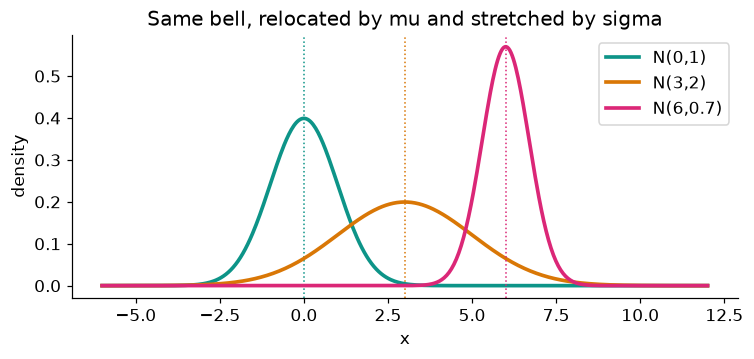

In [2]:
xs=np.linspace(-6,12,500)
fig,ax=plt.subplots(figsize=(7,3.4))
for mu,sd,c,lab in [(0,1,TEAL,"N(0,1)"),(3,2,AMBER,"N(3,2)"),(6,0.7,PINK,"N(6,0.7)")]:
    ax.plot(xs, stats.norm.pdf(xs,mu,sd), color=c, lw=2.4, label=lab)
    ax.axvline(mu, color=c, ls=":", lw=1)
ax.set_xlabel("x"); ax.set_ylabel("density"); ax.set_title("Same bell, relocated by mu and stretched by sigma"); ax.legend()
plt.tight_layout(); plt.show()

The peak always sits at mu, and the curve is symmetric, so mean = median = mode. A smaller sigma concentrates the area into a tall narrow spike; a larger sigma flattens it. These two numbers fully determine the entire distribution.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 2 · THE EMPIRICAL RULE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">68 - 95 - 99.7</div>
<div style="color:#4a5578;margin-top:6px">For any normal distribution, fixed fractions of the data fall within 1, 2, and 3 standard deviations of the mean. This is the famous 68-95-99.7 rule.</div>
</div>

In [3]:
for k in (1,2,3):
    frac = stats.norm.cdf(k) - stats.norm.cdf(-k)
    print(f"within +/- {k} sigma: {frac*100:.2f}% of the data")

# verify by simulation
data = rng.normal(0,1,size=1_000_000)
for k in (1,2,3):
    print(f"simulated within +/- {k} sigma: {np.mean(np.abs(data)<k)*100:.2f}%")

within +/- 1 sigma: 68.27% of the data
within +/- 2 sigma: 95.45% of the data
within +/- 3 sigma: 99.73% of the data
simulated within +/- 1 sigma: 68.28%
simulated within +/- 2 sigma: 95.51%
simulated within +/- 3 sigma: 99.74%


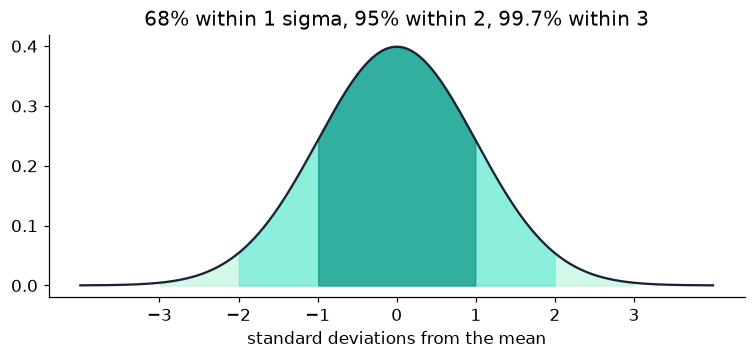

In [4]:
xs=np.linspace(-4,4,400); pdf=stats.norm.pdf(xs)
fig,ax=plt.subplots(figsize=(7,3.4))
ax.plot(xs,pdf,color="#1a2138",lw=1.5)
for k,c,a in [(3,"#a7f3d0",0.5),(2,"#5eead4",0.6),(1,TEAL,0.7)]:
    m=(xs>=-k)&(xs<=k); ax.fill_between(xs[m],pdf[m],color=c,alpha=a)
ax.set_title("68% within 1 sigma, 95% within 2, 99.7% within 3"); ax.set_xlabel("standard deviations from the mean")
ax.set_xticks([-3,-2,-1,0,1,2,3]); plt.tight_layout(); plt.show()

The percentages, 68.27%, 95.45%, and 99.73%, hold for every normal, whatever its mu and sigma. This is why "within two standard deviations" is shorthand for "almost all" and why a value beyond 3 sigma is genuinely surprising (under 0.3% of cases).

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 3 · STANDARDIZING TO z-SCORES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One scale to compare them all</div>
<div style="color:#4a5578;margin-top:6px">A z-score, z = (x - mu) / sigma, says how many standard deviations a value sits from its mean. It turns ANY normal into the standard normal N(0,1), making different scales comparable.</div>
</div>

In [5]:
sat = rng.normal(1050, 200, size=8)        # SAT-like scores
z = (sat - sat.mean()) / sat.std()
for s,zi in zip(sat, z):
    print(f"score {s:7.1f}  ->  z = {zi:+.2f}")
print(f"\nstandardized data: mean = {z.mean():.2f}, std = {z.std():.2f}")

score   759.3  ->  z = -0.97
score  1310.6  ->  z = +2.29
score   848.6  ->  z = -0.44
score   762.7  ->  z = -0.95
score   982.2  ->  z = +0.35
score   930.8  ->  z = +0.05
score   983.7  ->  z = +0.36
score   807.6  ->  z = -0.68

standardized data: mean = -0.00, std = 1.00


After standardizing, the data has mean 0 and standard deviation 1 by construction, the standard normal scale. A z of +2 means "two standard deviations above average", whether the raw value was a test score, a height, or a temperature. Standardization is what lets you compare apples to oranges.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 4 · PROBABILITIES &amp; PERCENTILES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Working in z</div>
<div style="color:#4a5578;margin-top:6px">Once standardized, probabilities come straight from the standard normal CDF (the z-table). The value z = 1.96 marks the central 95%, the number behind nearly every confidence interval.</div>
</div>

In [6]:
print(f"P(Z < 1)        = {stats.norm.cdf(1):.4f}")
print(f"P(Z > 2)        = {1-stats.norm.cdf(2):.4f}")
print(f"central 95% is z in +/- {stats.norm.ppf(0.975):.4f}")

# applied to N(100,15): what IQ is the 99th percentile?
print(f"99th percentile of N(100,15) = {stats.norm.ppf(0.99,100,15):.1f}")

P(Z < 1)        = 0.8413
P(Z > 2)        = 0.0228
central 95% is z in +/- 1.9600
99th percentile of N(100,15) = 134.9


The single number z = 1.96 captures the central 95% of any normal, which is why it appears in confidence intervals and significance tests throughout the rest of the book. Convert a value to z, look up the area, and you have its probability or percentile.

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0d9488;letter-spacing:1px">DEMO 5 · STANDARDIZATION IN MACHINE LEARNING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Why models z-score their features</div>
<div style="color:#4a5578;margin-top:6px">Most ML algorithms work far better when features share a scale. Standardizing each feature to mean 0, std 1 (a z-score) is the most common preprocessing step in all of machine learning.</div>
</div>

In [7]:
# two features on wildly different scales
age    = rng.normal(40, 12, size=1000)        # ~ tens
income = rng.normal(60000, 20000, size=1000)  # ~ tens of thousands
X = np.column_stack([age, income])
print(f"raw means {X.mean(0).round(1)},  raw stds {X.std(0).round(1)}")

Xz = (X - X.mean(0)) / X.std(0)               # standardize each column
print(f"scaled means {Xz.mean(0).round(3)},  scaled stds {Xz.std(0).round(3)}")

# z-scores also flag anomalies: |z| > 3 is a rare outlier
outliers = np.abs(Xz) > 3
print(f"points beyond 3 sigma (anomalies): {outliers.any(axis=1).sum()}")

raw means [4.00000e+01 5.96914e+04],  raw stds [1.22000e+01 1.99733e+04]
scaled means [-0.  0.],  scaled stds [1. 1.]
points beyond 3 sigma (anomalies): 7


Before scaling, income dwarfs age simply because its numbers are bigger, and distance-based or gradient-based models would be dominated by it. Standardizing puts every feature on the z-scale (mean 0, std 1) so each contributes fairly. The same z-scores double as an **anomaly detector**: any point beyond 3 sigma is, by the empirical rule, a rare outlier worth a look.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You confirmed the 68-95-99.7 rule, standardized data into z-scores, pulled probabilities and percentiles from the standard normal, and scaled features the way every ML pipeline does. The z-score, how many standard deviations from the mean, is one of the most useful numbers in statistics.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>